<a href="https://colab.research.google.com/github/gautamkushwaha/50-days-of-coding/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regression Using Neural Network**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

**Use GPU for processing**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
data = fetch_california_housing()
X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)

Features: (20640, 8)
Target: (20640,)


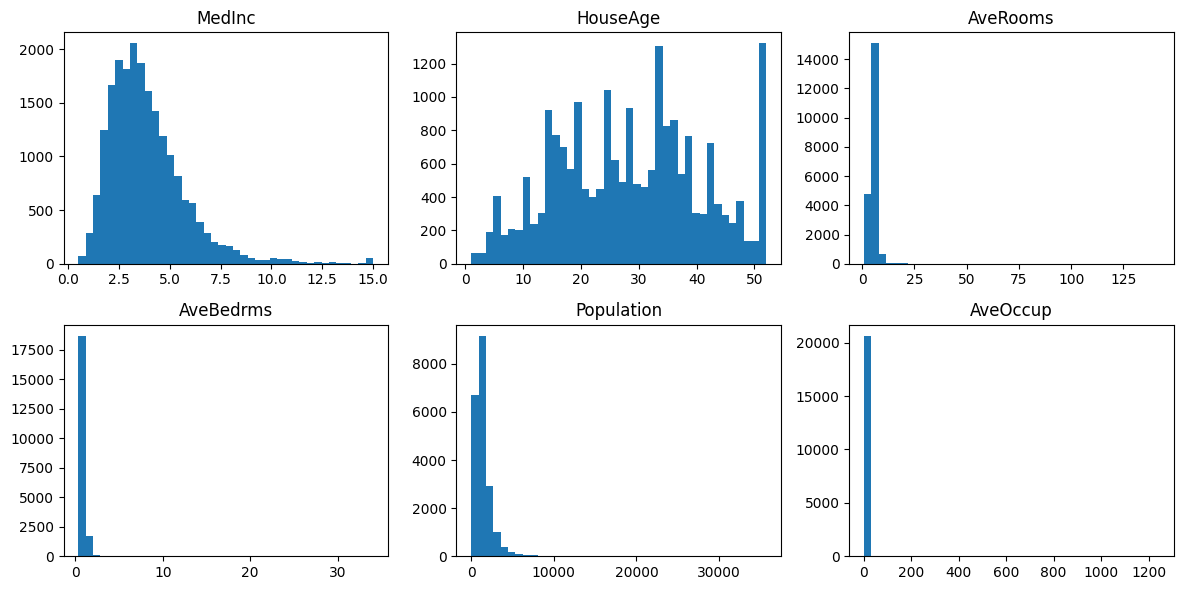

In [ ]:
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.hist(X[:, i], bins=40)
    plt.title(data.feature_names[i])
plt.tight_layout()
plt.show()

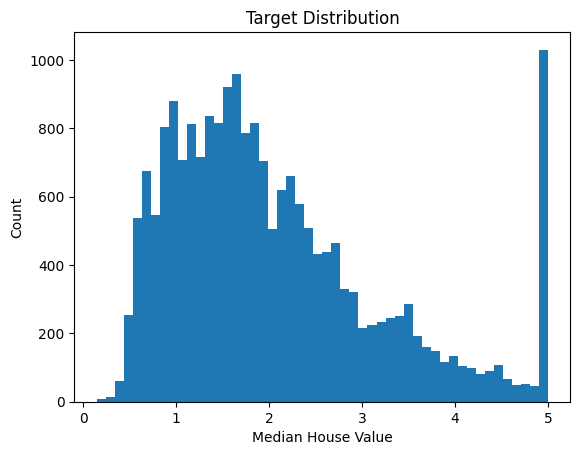

In [ ]:
plt.hist(y, bins=50)
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

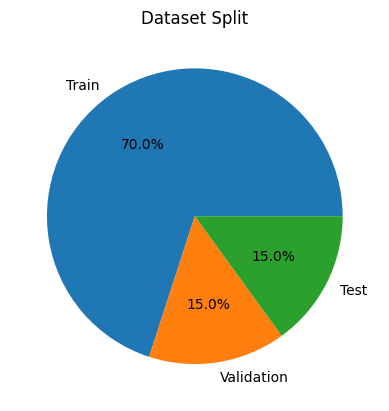

In [ ]:
sizes = [len(y_train), len(y_val), len(y_test)]
labels = ["Train", "Validation", "Test"]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Dataset Split")
plt.show()


**Standardize Features**

In [ ]:
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
eps = 1e-8
std = std + eps

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

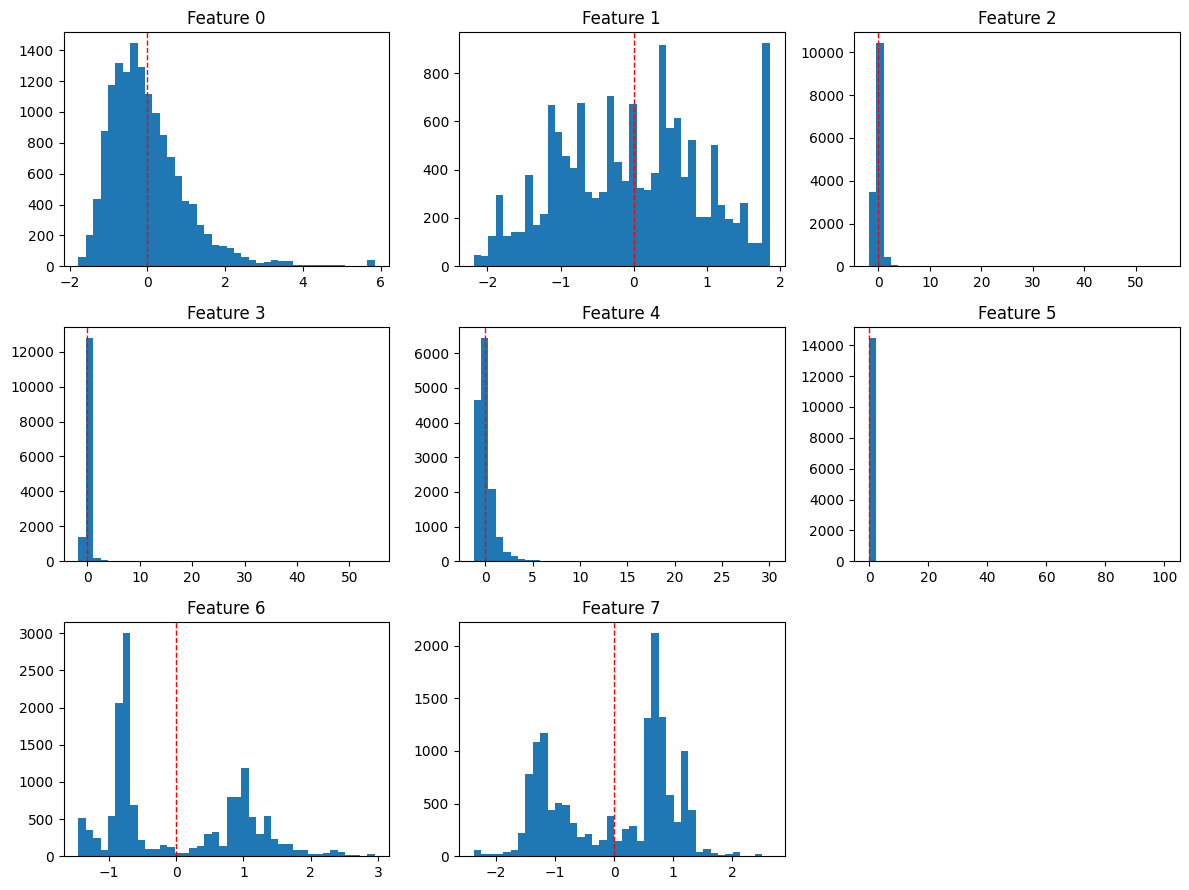

In [ ]:
num_features = X_train.shape[1]
cols = 3
rows = (num_features + cols - 1) // cols

plt.figure(figsize=(12, 3 * rows))

for i in range(num_features):
    plt.subplot(rows, cols, i + 1)
    plt.hist(X_train[:, i], bins=40)
    plt.title(f"Feature {i}")
    plt.axvline(0, color='r', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1,1).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1).to(device)


In [ ]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_batch_gd(X_train, y_train, X_val, y_val, epochs=10, lr=0.1):
    model = RegressionNet(X_train.shape[1]).to(device)
    criterion = nn.MSELoss(reduction="mean")
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    N = len(X_train)
    start = time.time()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        total_loss = 0.0
        for i in range(N):
            preds = model(X_train[i:i+1])
            loss_i = criterion(preds, y_train[i:i+1])
            total_loss += loss_i

        train_loss = total_loss / N
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        if (epoch + 1) % 1 == 0:
            print(
                f"Epoch {epoch:02d} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f}"
            )

    return train_losses, val_losses, time.time() - start, model

def train_sgd(X_train, y_train, X_val, y_val, epochs=5, lr=0.001):
    model = RegressionNet(X_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    N = len(X_train)
    start = time.time()

    for epoch in range(epochs):
        model.train()

        perm = torch.randperm(N)

        for idx, i in enumerate(perm):
            optimizer.zero_grad()
            preds = model(X_train[i:i+1])
            loss = criterion(preds, y_train[i:i+1])
            loss.backward()
            optimizer.step()
            if (idx+1) % 5000== 0:
                print(
                    f"Step: {idx+1:02d} | "
                    f"Step Loss: {loss.item():.4f} | "
                )
            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_train), y_train)
            val_loss = criterion(model(X_val), y_val)
        val_losses.append(val_loss.item())

        if (epoch+1) % 1 == 0:
            print(
                f"Epoch {epoch+1:02d} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f}"
            )

    return train_losses, val_losses, time.time() - start, model

def train_minibatch_gd(X_train, y_train, X_val, y_val,
                       batch_size=16, epochs=10, lr=0.01):
    model = RegressionNet(X_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    N = len(X_train)
    start = time.time()

    for epoch in range(epochs):
        model.train()

        perm = torch.randperm(N)
        total_loss = 0.0
        batch_idx = 0
        for idx, i in enumerate(perm):
            optimizer.zero_grad()
            preds = model(X_train[i:i+1])
            loss = criterion(preds, y_train[i:i+1])
            total_loss += loss
            if (idx+1)%batch_size==0:
                total_loss /= batch_size
                total_loss.backward()
                optimizer.step()
                batch_idx += 1
                if (batch_idx) % 400== 0:
                    print(
                        f"Batch: {batch_idx:02d} | "
                        f"Batch Loss: {total_loss.item():.4f} | "
                    )
                train_losses.append(total_loss.item())
                total_loss = 0.0

        model.eval()
        with torch.no_grad():
            train_loss = criterion(model(X_train), y_train)
            val_loss = criterion(model(X_val), y_val)
        val_losses.append(val_loss.item())

        if (epoch+1) % 1 == 0:
            print(
                f"Epoch {epoch+1:02d} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f}"
            )

    return train_losses, val_losses, time.time() - start, model

# **Training Neural Network**

**Gradient Decent**

In [ ]:
gd_tr, gd_val, time_taken, _ = train_batch_gd(X_train, y_train, X_val, y_val)
print(f"Finished in: {time_taken} sec")

Epoch 00 | Train Loss: 6.3700 | Val Loss: 2.8173
Epoch 01 | Train Loss: 2.9094 | Val Loss: 1.5426
Epoch 02 | Train Loss: 1.7290 | Val Loss: 1.2907
Epoch 03 | Train Loss: 1.4358 | Val Loss: 1.1657
Epoch 04 | Train Loss: 1.2493 | Val Loss: 1.0561
Epoch 05 | Train Loss: 1.1104 | Val Loss: 0.9696
Epoch 06 | Train Loss: 1.0005 | Val Loss: 0.8971
Epoch 07 | Train Loss: 0.9120 | Val Loss: 0.8392
Epoch 08 | Train Loss: 0.8418 | Val Loss: 0.7939
Epoch 09 | Train Loss: 0.7879 | Val Loss: 0.7597
Finished in: 54.36933636665344 sec


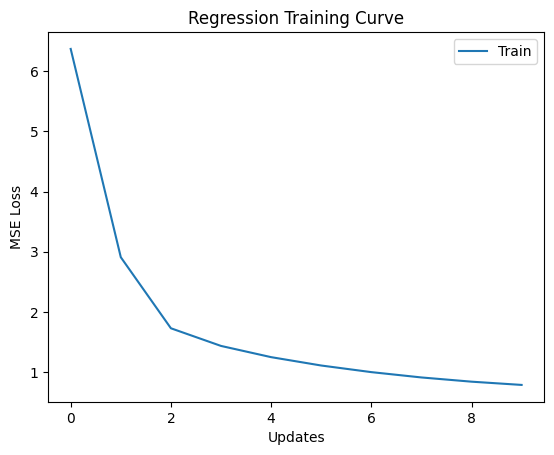

In [ ]:
plt.plot(gd_tr, label="Train")
plt.xlabel("Updates")
plt.ylabel("MSE Loss")
plt.title("Regression Training Curve")
plt.legend()
plt.show()

**Stochastic Gradient Decent**

In [ ]:
sgd_tr, sgd_val, time_taken, _ = train_sgd(X_train, y_train, X_val, y_val)
print(f"Finished in: {time_taken} sec")

Step: 5000 | Step Loss: 0.0093 | 
Step: 10000 | Step Loss: 0.0859 | 
Epoch 01 | Train Loss: 0.4458 | Val Loss: 0.4494
Step: 5000 | Step Loss: 0.3252 | 
Step: 10000 | Step Loss: 0.0375 | 
Epoch 02 | Train Loss: 0.4753 | Val Loss: 0.4901
Step: 5000 | Step Loss: 0.3741 | 
Step: 10000 | Step Loss: 0.0010 | 
Epoch 03 | Train Loss: 0.3770 | Val Loss: 0.3982
Step: 5000 | Step Loss: 0.2519 | 
Step: 10000 | Step Loss: 0.0088 | 
Epoch 04 | Train Loss: 0.3510 | Val Loss: 0.3685
Step: 5000 | Step Loss: 0.0511 | 
Step: 10000 | Step Loss: 0.3818 | 
Epoch 05 | Train Loss: 0.3449 | Val Loss: 0.3619
Finished in: 51.201056480407715 sec


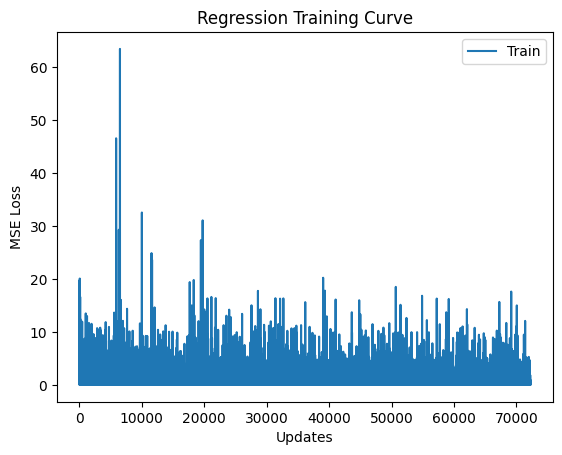

In [ ]:
sgd_tr = np.array(sgd_tr)
sgd_val = np.array(sgd_val)

x_train = np.arange(len(sgd_tr))
x_val = np.linspace(0, len(sgd_tr) - 1, num=len(sgd_val))

sgd_val_stretched = np.interp(x_train, x_val, sgd_val)

plt.plot(x_train, sgd_tr, label="Train")
plt.xlabel("Updates")
plt.ylabel("MSE Loss")
plt.title("Regression Training Curve")
plt.legend()
plt.show()

**Mini-Batch Gradient Decent**

In [ ]:
mb_tr, mb_val, time_taken, model = train_minibatch_gd(X_train, y_train, X_val, y_val)
print(f"Finished in: {time_taken} sec")

Batch: 400 | Batch Loss: 0.4592 | 
Batch: 800 | Batch Loss: 0.5238 | 
Epoch 01 | Train Loss: 0.5112 | Val Loss: 0.5165
Batch: 400 | Batch Loss: 0.3812 | 
Batch: 800 | Batch Loss: 0.4414 | 
Epoch 02 | Train Loss: 0.4224 | Val Loss: 0.4445
Batch: 400 | Batch Loss: 0.5031 | 
Batch: 800 | Batch Loss: 0.2940 | 
Epoch 03 | Train Loss: 0.4036 | Val Loss: 0.4231
Batch: 400 | Batch Loss: 0.1448 | 
Batch: 800 | Batch Loss: 0.5352 | 
Epoch 04 | Train Loss: 0.3981 | Val Loss: 0.4215
Batch: 400 | Batch Loss: 0.5560 | 
Batch: 800 | Batch Loss: 0.1135 | 
Epoch 05 | Train Loss: 0.3580 | Val Loss: 0.3877
Batch: 400 | Batch Loss: 0.6551 | 
Batch: 800 | Batch Loss: 0.1670 | 
Epoch 06 | Train Loss: 0.3524 | Val Loss: 0.3800
Batch: 400 | Batch Loss: 0.0774 | 
Batch: 800 | Batch Loss: 0.2335 | 
Epoch 07 | Train Loss: 0.3503 | Val Loss: 0.3793
Batch: 400 | Batch Loss: 0.2071 | 
Batch: 800 | Batch Loss: 0.1748 | 
Epoch 08 | Train Loss: 0.3291 | Val Loss: 0.3576
Batch: 400 | Batch Loss: 0.3459 | 
Batch: 800 | 

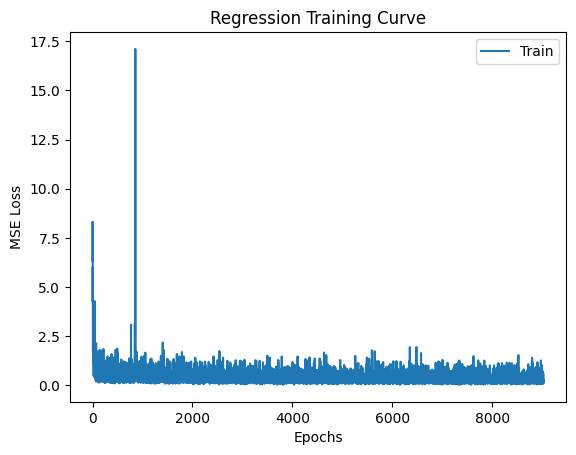

In [ ]:
def to_numpy(x):
    return np.array([
        v.detach().cpu().item() if torch.is_tensor(v) else v
        for v in x
    ])
mb_tr = to_numpy(mb_tr)
mb_val = to_numpy(mb_val)

x_train = np.arange(len(mb_tr))
x_val = np.linspace(0, len(mb_tr) - 1, num=len(mb_val))

mb_val_stretched = np.interp(x_train, x_val, mb_val)

plt.plot(x_train, mb_tr, label="Train")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Regression Training Curve")
plt.legend()
plt.show()

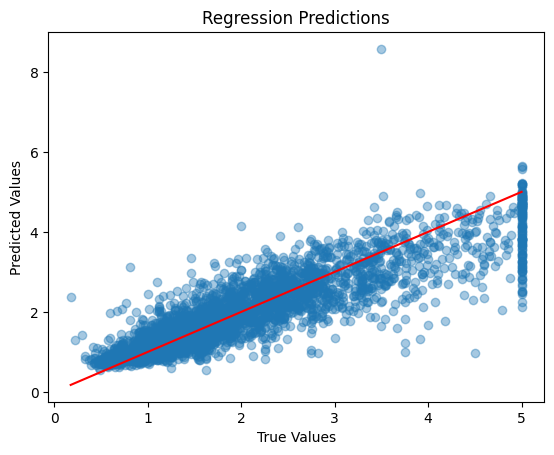

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test).cpu().numpy()

y_test_cpu = y_test.cpu().numpy().flatten()
y_pred_cpu = y_pred.flatten()

plt.scatter(y_test_cpu, y_pred_cpu, alpha=0.4)

min_val = y_test_cpu.min()
max_val = y_test_cpu.max()

plt.plot([min_val, max_val], [min_val, max_val], 'r')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Regression Predictions")
plt.show()

# **Classification Using Neural Network**

In [ ]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

train_data = MNIST(root=".", train=True, download=True, transform=ToTensor())
test_data  = MNIST(root=".", train=False, download=True, transform=ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 107MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 36.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 107MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.03MB/s]


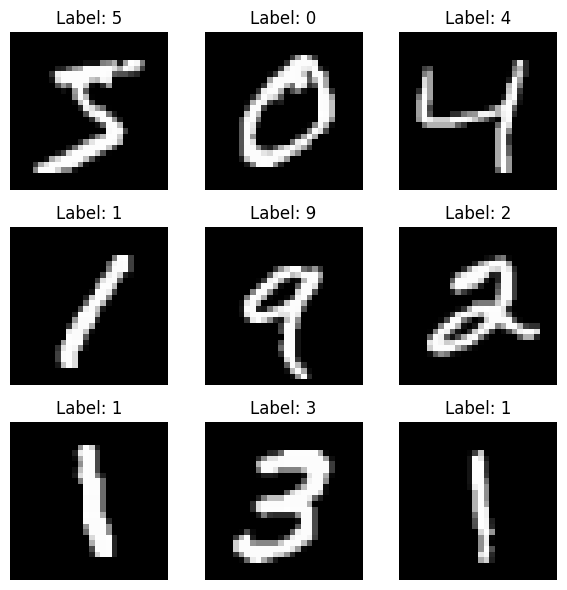

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9):
    img, label = train_data[i]
    plt.subplot(3,3,i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def prepare(dataset):
    X = dataset.data.view(len(dataset), -1).float() / 255.0
    y = dataset.targets
    return X, y

X, y = prepare(train_data)
X_test, y_test = prepare(test_data)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    drop_last=False
)

In [ ]:
def one_hot(labels, num_classes=10):
    return torch.eye(num_classes)[labels]

y_train_oh = one_hot(y_train)
y_val_oh   = one_hot(y_val)
y_test_oh  = one_hot(y_test)

**One-hot Encoding**

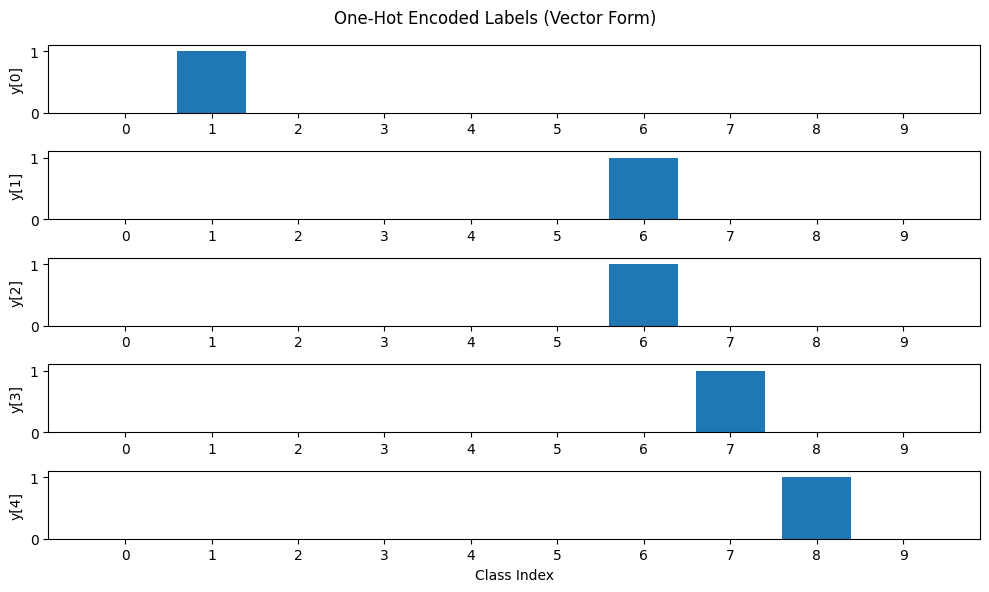

In [ ]:
plt.figure(figsize=(10,6))

for i in range(5):
    plt.subplot(5, 1, i+1)
    plt.bar(range(10), y_train_oh[i].numpy())
    plt.xticks(range(10))
    plt.ylim(0, 1.1)
    plt.ylabel(f"y[{i}]")

plt.xlabel("Class Index")
plt.suptitle("One-Hot Encoded Labels (Vector Form)")
plt.tight_layout()
plt.show()


In [ ]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
def train_model(model, optimizer, epochs=10, batch_size=32):
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    val_acc = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        acc = correct / total
        val_acc.append(acc)

        if (epoch + 1) % 1 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train Loss: {avg_loss:.4f} | "
                f"Val Acc: {acc:.4f}"
            )

    return val_acc

In [ ]:
histories = {}

print("\nTraining with SGD (lr=0.1, momentum=0.9)")
model = MNISTNet()
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

histories["SGD"] = train_model(
    model, optimizer
)

print("\nTraining with Adagrad (lr=0.01)")
model = MNISTNet()
optimizer = torch.optim.Adagrad(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-4
)

histories["Adagrad"] = train_model(
    model, optimizer
)

print("\nTraining with RMSProp (lr=0.001, alpha=0.99)")
model = MNISTNet()
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=0.001,
    alpha=0.99,
    weight_decay=1e-4
)

histories["RMSProp"] = train_model(
    model, optimizer
)

print("\nTraining with Adam (lr=0.001)")
model = MNISTNet()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    betas=(0.9, 0.999),
    weight_decay=1e-4
)

histories["Adam"] = train_model(
    model, optimizer
)



Training with SGD (lr=0.1, momentum=0.9)
Epoch [1/10] | Train Loss: 0.3644 | Val Acc: 0.9282
Epoch [2/10] | Train Loss: 0.2214 | Val Acc: 0.9528
Epoch [3/10] | Train Loss: 0.1860 | Val Acc: 0.9478
Epoch [4/10] | Train Loss: 0.1682 | Val Acc: 0.9555
Epoch [5/10] | Train Loss: 0.1570 | Val Acc: 0.9522
Epoch [6/10] | Train Loss: 0.1472 | Val Acc: 0.9615
Epoch [7/10] | Train Loss: 0.1377 | Val Acc: 0.9552
Epoch [8/10] | Train Loss: 0.1354 | Val Acc: 0.9540
Epoch [9/10] | Train Loss: 0.1290 | Val Acc: 0.9600
Epoch [10/10] | Train Loss: 0.1239 | Val Acc: 0.9582

Training with Adagrad (lr=0.01)
Epoch [1/10] | Train Loss: 0.2970 | Val Acc: 0.9437
Epoch [2/10] | Train Loss: 0.1783 | Val Acc: 0.9525
Epoch [3/10] | Train Loss: 0.1478 | Val Acc: 0.9585
Epoch [4/10] | Train Loss: 0.1296 | Val Acc: 0.9608
Epoch [5/10] | Train Loss: 0.1166 | Val Acc: 0.9640
Epoch [6/10] | Train Loss: 0.1063 | Val Acc: 0.9652
Epoch [7/10] | Train Loss: 0.0986 | Val Acc: 0.9663
Epoch [8/10] | Train Loss: 0.0914 | Val 

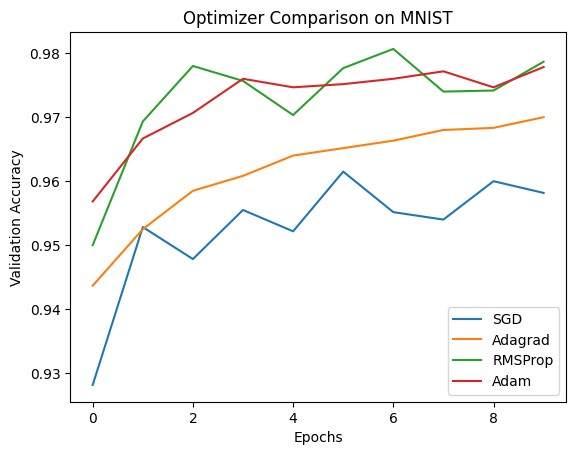

In [ ]:
for name, acc in histories.items():
    plt.plot(acc, label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison on MNIST")
plt.legend()
plt.show()



Training with Adam (lr=0.0001)
Epoch [1/10] | Train Loss: 0.3133 | Val Acc: 0.9555
Epoch [2/10] | Train Loss: 0.1320 | Val Acc: 0.9683
Epoch [3/10] | Train Loss: 0.0905 | Val Acc: 0.9723
Epoch [4/10] | Train Loss: 0.0705 | Val Acc: 0.9732
Epoch [5/10] | Train Loss: 0.0572 | Val Acc: 0.9768
Epoch [6/10] | Train Loss: 0.0500 | Val Acc: 0.9788
Epoch [7/10] | Train Loss: 0.0423 | Val Acc: 0.9758
Epoch [8/10] | Train Loss: 0.0373 | Val Acc: 0.9752
Epoch [9/10] | Train Loss: 0.0329 | Val Acc: 0.9785
Epoch [10/10] | Train Loss: 0.0308 | Val Acc: 0.9773

Training with Adam (lr=0.001)
Epoch [1/10] | Train Loss: 0.3044 | Val Acc: 0.9555
Epoch [2/10] | Train Loss: 0.1259 | Val Acc: 0.9675
Epoch [3/10] | Train Loss: 0.0896 | Val Acc: 0.9717
Epoch [4/10] | Train Loss: 0.0692 | Val Acc: 0.9722
Epoch [5/10] | Train Loss: 0.0570 | Val Acc: 0.9738
Epoch [6/10] | Train Loss: 0.0477 | Val Acc: 0.9745
Epoch [7/10] | Train Loss: 0.0412 | Val Acc: 0.9767
Epoch [8/10] | Train Loss: 0.0369 | Val Acc: 0.9802


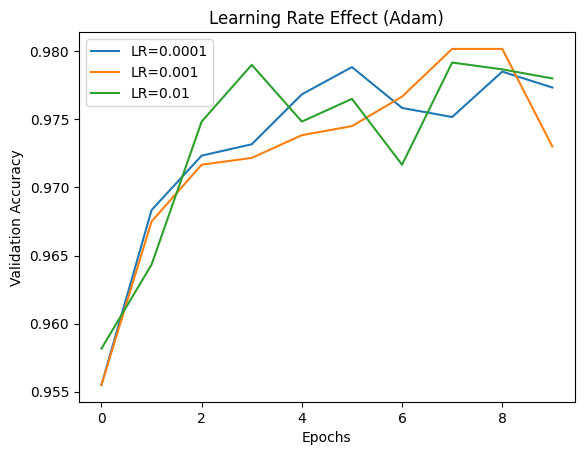

In [ ]:
lrs = [0.0001, 0.001, 0.01]

for lr in lrs:
    print(f"\nTraining with Adam (lr={lr})")
    model = MNISTNet()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001,
        betas=(0.9, 0.999),
        weight_decay=1e-4
    )

    acc = train_model(
        model, optimizer
    )
    plt.plot(acc, label=f"LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate Effect (Adam)")
plt.legend()
plt.show()

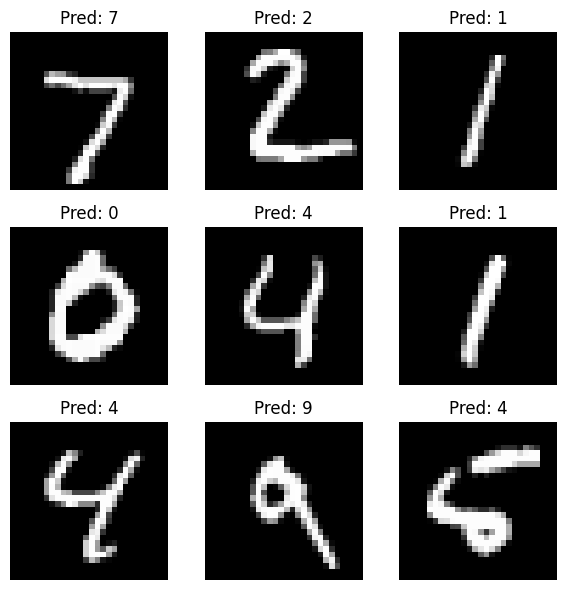

In [ ]:
model.eval()
with torch.no_grad():
    preds = torch.argmax(model(X_test[:9].to(device)), dim=1)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].view(28,28), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# **Assignment 1**

Implement a fully connected neural network (MLP) using PyTorch to classify the MNIST handwritten digit dataset. Preprocess the data by flattening each image into a 1D vector and normalizing it. Experiment with different numbers of hidden layers, neurons per layer, activation functions, optimizers, and learning rates to obtain the best classification performance. Use a proper train–validation–test split. Report accuracy, precision, recall, and F1-score on the test set, and plot training vs validation loss curves to analyze model behavior and overfitting.

- Use PyTorch only
- Use fully connected layers only (no CNNs)
- Plot training vs validation loss for your experiments
- Report accuracy, precision, recall, and F1-score
- Clearly mention the best-performing model configuration